 MANDATORY VALIDATION: Raised-Cosine Sample Values


,Alpha = 0,Alpha = 0.25,Alpha = 0.5,Alpha = 1.0
t = -2T,-3.898172e-17,-1.949086e-17,-1.299391e-17,2.598781e-18
t = -1T,3.898172e-17,3.675232e-17,1.949086e-17,1.299391e-17
t = 0T,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
t = 1T,3.898172e-17,3.675232e-17,1.949086e-17,1.299391e-17
t = 2T,-3.898172e-17,-1.949086e-17,-1.299391e-17,2.598781e-18


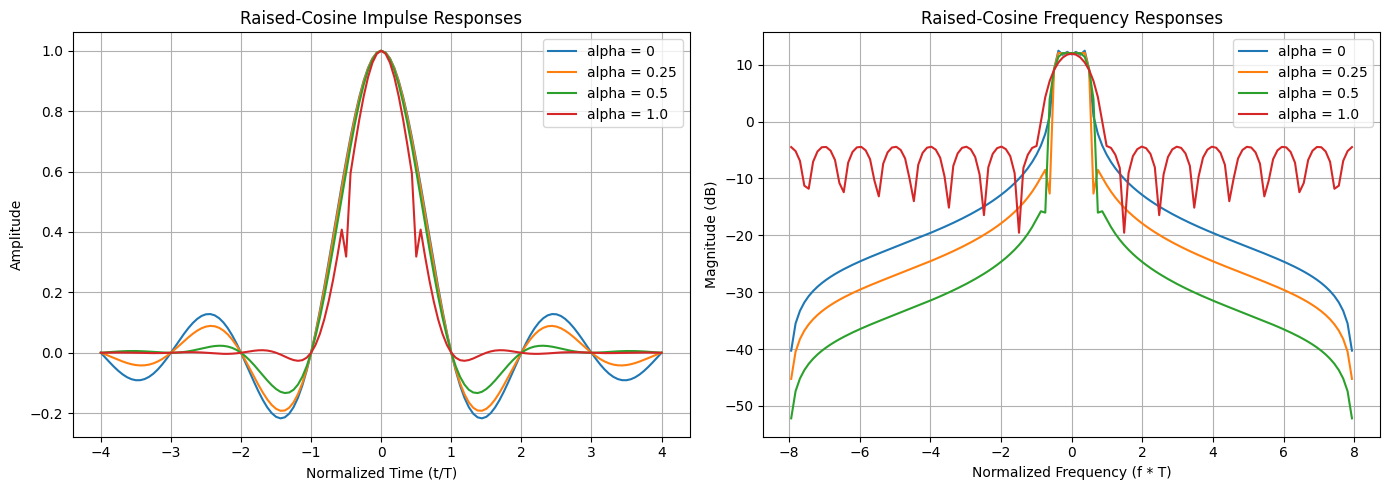

In [2]:
# Experiment 7 — Pulse shaping and the Nyquist criterion (With Tabulated Values)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Simulation Parameters
T_s = 1.0           # Symbol period
oversample = 16     # Oversampling factor
t_span = 4
t = np.linspace(-t_span * T_s, t_span * T_s, 2 * t_span * oversample + 1)
alphas = [0, 0.25, 0.5, 1.0] # Roll-off factors

# Raised-Cosine function definition
def raised_cosine_pulse(t, T, alpha):
    h = np.zeros_like(t)
    for i, val in enumerate(t):
        if val == 0:
            h[i] = 1.0
        elif alpha != 0 and np.isclose(np.abs(2 * alpha * val / T), 1.0):
            h[i] = (alpha / 2.0) * np.sin(np.pi / (2.0 * alpha)) / (np.pi / 2.0)
        else:
            if alpha == 0:
                h[i] = np.sinc(val / T)
            else:
                h[i] = np.sinc(val / T) * np.cos(np.pi * alpha * val / T) / (1.0 - (2.0 * alpha * val / T)**2)
    return h

# --- MANDATORY VALIDATION: Tabulate values at integer symbol intervals ---
t_integers = np.array([-2, -1, 0, 1, 2], dtype=float) * T_s
table_data = {}

for alpha in alphas:
    h_vals = raised_cosine_pulse(t_integers, T_s, alpha)
    table_data[f'Alpha = {alpha}'] = h_vals

df_validation = pd.DataFrame(table_data, index=[f't = {int(val/T_s)}T' for val in t_integers])

print("==================================================")
print(" MANDATORY VALIDATION: Raised-Cosine Sample Values")
print("==================================================")
display(df_validation)
print("\n")

# --- PLOTTING GRAPHS ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for alpha in alphas:
    h_rc = raised_cosine_pulse(t, T_s, alpha)
    plt.plot(t / T_s, h_rc, label=f'alpha = {alpha}')
plt.title('Raised-Cosine Impulse Responses')
plt.xlabel('Normalized Time (t/T)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for alpha in alphas:
    h_rc = raised_cosine_pulse(t, T_s, alpha)
    freq = np.fft.fftshift(np.fft.fftfreq(len(h_rc), d=(t[1] - t[0])))
    H_rc = np.fft.fftshift(np.fft.fft(h_rc))
    plt.plot(freq * T_s, 10 * np.log10(np.abs(H_rc) + 1e-10), label=f'alpha = {alpha}')
plt.title('Raised-Cosine Frequency Responses')
plt.xlabel('Normalized Frequency (f * T)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()